Nombre de patients : 569
Nombre de variables : 30
- L'accuracy sur le jeu de test indique la capacité du perceptron à distinguer les patients malades des non malades.

Accuracy : 95.61%


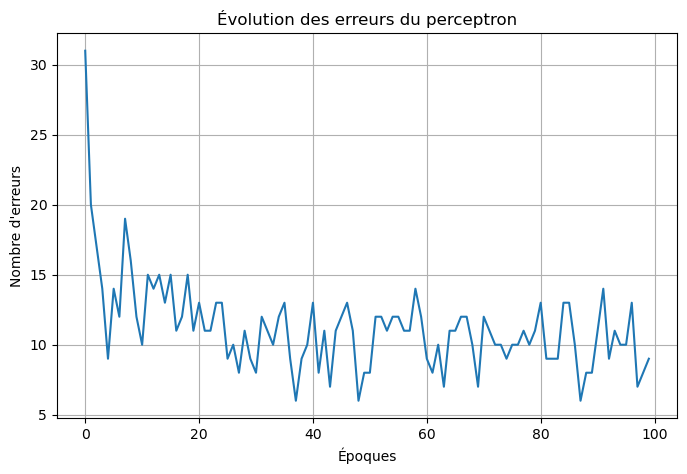

- La matrice de confusion permet d'identifier les erreurs de classification et de vérifier l'équilibre entre les classes.

===== MATRICE DE CONFUSION =====
TP = 41
TN = 68
FP = 3
FN = 2


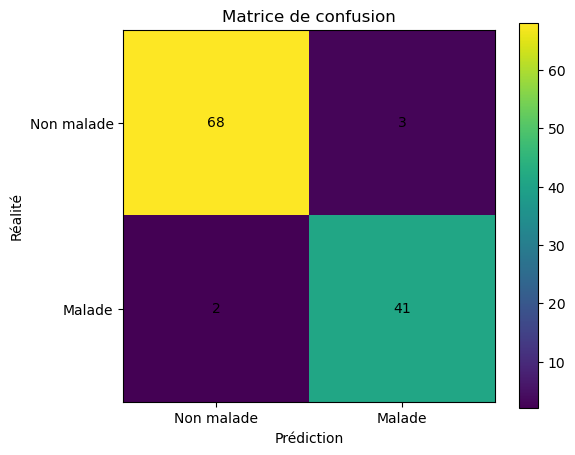

- La visualisation PCA illustre la séparation des deux groupes par une frontière de décision linéaire.


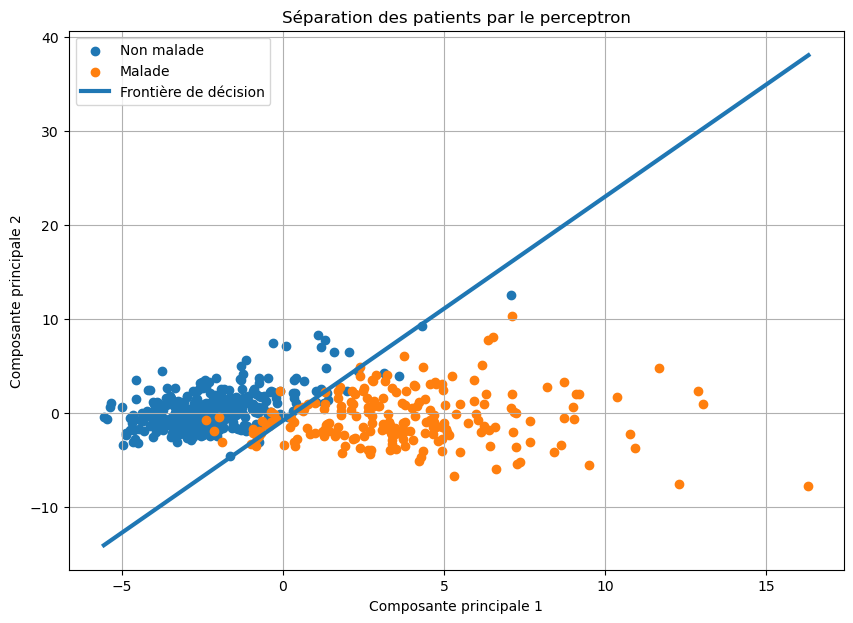


PREDICTION D'UN NOUVEAU PATIENT

Veuillez saisir les caractéristiques du patient :



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
# supprimer cette ligne
# from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# =====================================================
# 1. Chargement des données
# =====================================================

df = pd.read_csv("breast.csv")

# Encodage de la cible
df["Diagnosis"] = df["Diagnosis"].map({"M":1, "B":0})

# Variables explicatives
X = df.drop(["ID", "Diagnosis"], axis=1).values
y = df["Diagnosis"].values

print("Nombre de patients :", len(y))
print("Nombre de variables :", X.shape[1])

# =====================================================
# 2. Normalisation
# =====================================================

mean_X = X.mean(axis=0)
std_X = X.std(axis=0)

X = (X - mean_X) / std_X
# =====================================================
# 3. Train / Test
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# =====================================================
# 4. Perceptron From Scratch
# =====================================================
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        self.errors = []

        for _ in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                z = np.dot(xi, self.weights) + self.bias

                prediction = self.activation(z)

                update = self.lr * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.activation(z)

# =====================================================
# 5. Entraînement
# =====================================================

model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model.fit(X_train, y_train)

# =====================================================
# 6. Accuracy FROM SCRATCH
# =====================================================
print("- L'accuracy sur le jeu de test indique la capacité du perceptron à distinguer les patients malades des non malades.")
y_pred = model.predict(X_test)

acc = np.mean(y_pred == y_test)

print(f"\nAccuracy : {acc*100:.2f}%")
# =====================================================
# 7. Courbe d'apprentissage
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(model.errors)
plt.xlabel("Époques")
plt.ylabel("Nombre d'erreurs")
plt.title("Évolution des erreurs du perceptron")
plt.grid()
plt.savefig("courbe_apprentissage.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 8. Matrice de confusion FROM SCRATCH
# =====================================================
print("- La matrice de confusion permet d'identifier les erreurs de classification et de vérifier l'équilibre entre les classes.")
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

print("\n===== MATRICE DE CONFUSION =====")
print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

# Affichage graphique manuel

matrice = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6,5))

plt.imshow(matrice)

plt.colorbar()

plt.xticks(
    [0,1],
    ["Non malade", "Malade"]
)

plt.yticks(
    [0,1],
    ["Non malade", "Malade"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            matrice[i,j],
            ha="center",
            va="center"
        )

plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.savefig("matrice_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 9. Visualisation PCA 2D
# =====================================================
print("- La visualisation PCA illustre la séparation des deux groupes par une frontière de décision linéaire.")
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Réentraînement uniquement pour affichage
model_pca = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model_pca.fit(X_pca, y)

# =====================================================
# 10. Frontière de décision
# =====================================================

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    label="Non malade"
)

plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    label="Malade"
)

w = model_pca.weights
b = model_pca.bias

x_values = np.linspace(
    X_pca[:,0].min(),
    X_pca[:,0].max(),
    200
)

y_values = -(w[0]*x_values + b)/w[1]

plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label="Frontière de décision"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Séparation des patients par le perceptron")
plt.legend()
plt.grid()
plt.savefig("frontiere_decision.png", dpi=300, bbox_inches="tight")
plt.show()
# =====================================================
# 11. PREDICTION D'UN NOUVEAU PATIENT
# =====================================================

print("\n" + "="*50)
print("PREDICTION D'UN NOUVEAU PATIENT")
print("="*50)

# Liste des variables utilisées
feature_names = df.drop(["ID", "Diagnosis"], axis=1).columns

nouveau_patient = []

print("\nVeuillez saisir les caractéristiques du patient :\n")

for i, feature in enumerate(feature_names, start=1):

    mini = df[feature].min()
    maxi = df[feature].max()

    valeur = float(
        input(
            f"{i:02d}. {feature} "
            f"[entre {mini:.2f} et {maxi:.2f}] : "
        )
    )

    nouveau_patient.append(valeur)

# Transformation en tableau numpy
nouveau_patient = np.array([nouveau_patient])

# Normalisation du nouveau patient

nouveau_patient = (
    nouveau_patient - mean_X
) / std_X
# Prédiction
prediction = model.predict(nouveau_patient)

# Score du perceptron
z = np.dot(
    nouveau_patient,
    model.weights
) + model.bias

print("\nScore du perceptron (z) :", z[0])

print("\n" + "="*50)
print("RESULTAT DE LA PREDICTION")
print("="*50)

if prediction[0] == 1:
    print("Diagnostic prédit : TUMEUR MALIGNE (cancer)")
else:
    print("Diagnostic prédit : TUMEUR BENIGNE (pas de cancer)")
   # =====================================================
# VISUALISATION DU NOUVEAU PATIENT
# =====================================================

# Projection PCA du nouveau patient
x_vis = pca.transform(nouveau_patient)

plt.figure(figsize=(10,7))

# Patients bénignes(pas de cancer)
plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    alpha=0.6,
    label="Tumeur bénigne(non malade)"
)

# Patients malades
plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    alpha=0.6,
    label="Tumeur maligne(malade)"
)

# Frontière de décision
plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label="Frontière de décision"
)

# Nouveau patient
plt.scatter(
    x_vis[0,0],
    x_vis[0,1],
    marker="X",
    s=300,
    label="Nouveau patient"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Position du nouveau patient")
plt.legend()
plt.grid()
plt.savefig("nouveau_patient.png", dpi=300, bbox_inches="tight")
plt.show()

df

Nombre de patients : 569
Nombre de variables : 30
- L'accuracy sur le jeu de test indique la capacité du perceptron à distinguer les patients malades des non malades.

Accuracy : 95.61%


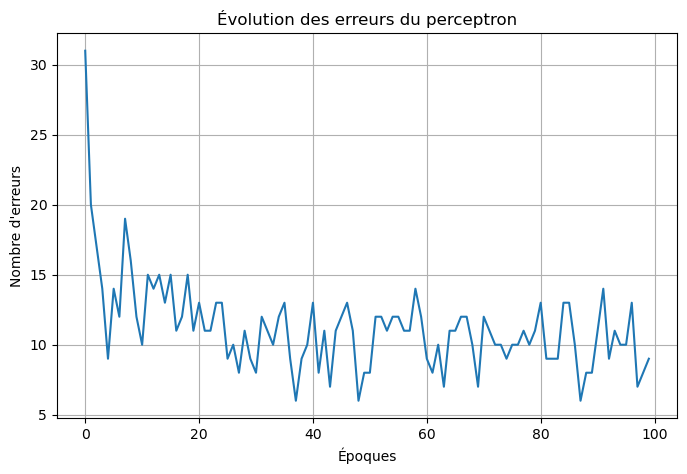

- La matrice de confusion permet d'identifier les erreurs de classification et de vérifier l'équilibre entre les classes.

===== MATRICE DE CONFUSION =====
TP = 41
TN = 68
FP = 3
FN = 2


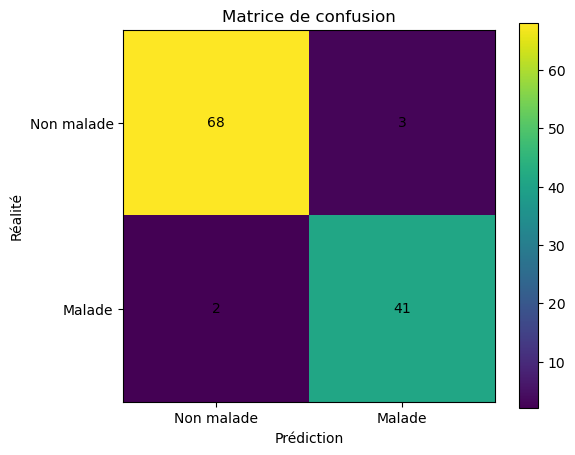

- La visualisation PCA illustre la séparation des deux groupes par une frontière de décision linéaire.


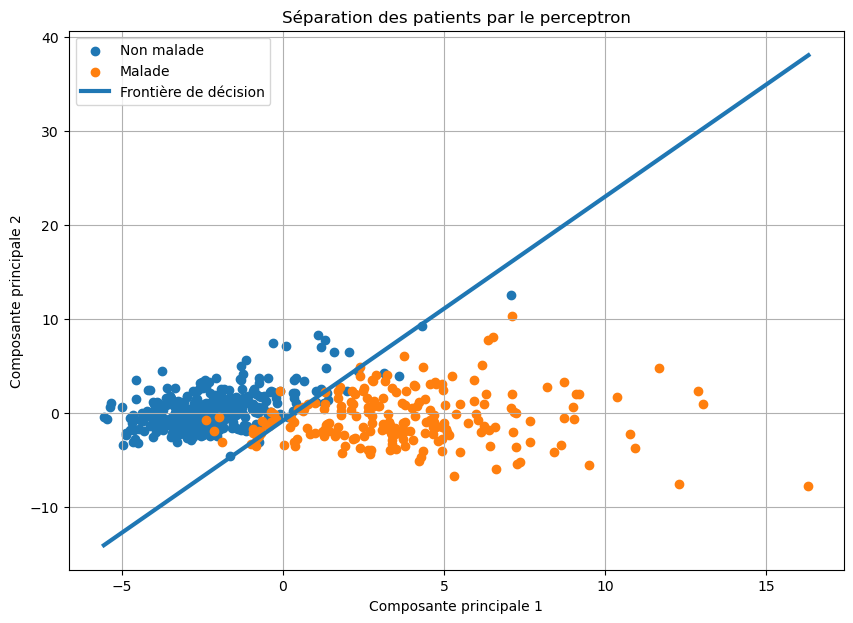


PREDICTION D'UN NOUVEAU PATIENT

Veuillez saisir les caractéristiques du patient :



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
# supprimer cette ligne
# from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# =====================================================
# 1. Chargement des données
# =====================================================

df = pd.read_csv("breast.csv")

# Encodage de la cible
df["Diagnosis"] = df["Diagnosis"].map({"M":1, "B":0})

# Variables explicatives
X = df.drop(["ID", "Diagnosis"], axis=1).values
y = df["Diagnosis"].values

print("Nombre de patients :", len(y))
print("Nombre de variables :", X.shape[1])

# =====================================================
# 2. Normalisation
# =====================================================

mean_X = X.mean(axis=0)
std_X = X.std(axis=0)

X = (X - mean_X) / std_X
# =====================================================
# 3. Train / Test
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# =====================================================
# 4. Perceptron From Scratch
# =====================================================
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs

    def activation(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        self.errors = []

        for _ in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                z = np.dot(xi, self.weights) + self.bias

                prediction = self.activation(z)

                update = self.lr * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.activation(z)

# =====================================================
# 5. Entraînement
# =====================================================

model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model.fit(X_train, y_train)

# =====================================================
# 6. Accuracy FROM SCRATCH
# =====================================================
print("- L'accuracy sur le jeu de test indique la capacité du perceptron à distinguer les patients malades des non malades.")
y_pred = model.predict(X_test)

acc = np.mean(y_pred == y_test)

print(f"\nAccuracy : {acc*100:.2f}%")
# =====================================================
# 7. Courbe d'apprentissage
# =====================================================

plt.figure(figsize=(8,5))
plt.plot(model.errors)
plt.xlabel("Époques")
plt.ylabel("Nombre d'erreurs")
plt.title("Évolution des erreurs du perceptron")
plt.grid()
plt.savefig("courbe_apprentissage.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 8. Matrice de confusion FROM SCRATCH
# =====================================================
print("- La matrice de confusion permet d'identifier les erreurs de classification et de vérifier l'équilibre entre les classes.")
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

print("\n===== MATRICE DE CONFUSION =====")
print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

# Affichage graphique manuel

matrice = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6,5))

plt.imshow(matrice)

plt.colorbar()

plt.xticks(
    [0,1],
    ["Non malade", "Malade"]
)

plt.yticks(
    [0,1],
    ["Non malade", "Malade"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            matrice[i,j],
            ha="center",
            va="center"
        )

plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.savefig("matrice_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

# =====================================================
# 9. Visualisation PCA 2D
# =====================================================
print("- La visualisation PCA illustre la séparation des deux groupes par une frontière de décision linéaire.")
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Réentraînement uniquement pour affichage
model_pca = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model_pca.fit(X_pca, y)

# =====================================================
# 10. Frontière de décision
# =====================================================

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    label="Non malade"
)

plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    label="Malade"
)

w = model_pca.weights
b = model_pca.bias

x_values = np.linspace(
    X_pca[:,0].min(),
    X_pca[:,0].max(),
    200
)

y_values = -(w[0]*x_values + b)/w[1]

plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label="Frontière de décision"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Séparation des patients par le perceptron")
plt.legend()
plt.grid()
plt.savefig("frontiere_decision.png", dpi=300, bbox_inches="tight")
plt.show()
# =====================================================
# 11. PREDICTION D'UN NOUVEAU PATIENT
# =====================================================

print("\n" + "="*50)
print("PREDICTION D'UN NOUVEAU PATIENT")
print("="*50)

# Liste des variables utilisées
feature_names = df.drop(["ID", "Diagnosis"], axis=1).columns

nouveau_patient = []

print("\nVeuillez saisir les caractéristiques du patient :\n")

for i, feature in enumerate(feature_names, start=1):

    mini = df[feature].min()
    maxi = df[feature].max()

    valeur = float(
        input(
            f"{i:02d}. {feature} "
            f"[entre {mini:.2f} et {maxi:.2f}] : "
        )
    )

    nouveau_patient.append(valeur)

# Transformation en tableau numpy
nouveau_patient = np.array([nouveau_patient])

# Normalisation du nouveau patient

nouveau_patient = (
    nouveau_patient - mean_X
) / std_X
# Prédiction
prediction = model.predict(nouveau_patient)

# Score du perceptron
z = np.dot(
    nouveau_patient,
    model.weights
) + model.bias

print("\nScore du perceptron (z) :", z[0])

print("\n" + "="*50)
print("RESULTAT DE LA PREDICTION")
print("="*50)

if prediction[0] == 1:
    print("Diagnostic prédit : TUMEUR MALIGNE (cancer)")
else:
    print("Diagnostic prédit : TUMEUR BENIGNE (pas de cancer)")
   # =====================================================
# VISUALISATION DU NOUVEAU PATIENT
# =====================================================

# Projection PCA du nouveau patient
x_vis = pca.transform(nouveau_patient)

plt.figure(figsize=(10,7))

# Patients bénignes(pas de cancer)
plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    alpha=0.6,
    label="Tumeur bénigne(non malade)"
)

# Patients malades
plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    alpha=0.6,
    label="Tumeur maligne(malade)"
)

# Frontière de décision
plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label="Frontière de décision"
)

# Nouveau patient
plt.scatter(
    x_vis[0,0],
    x_vis[0,1],
    marker="X",
    s=300,
    label="Nouveau patient"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Position du nouveau patient")
plt.legend()
plt.grid()
plt.savefig("nouveau_patient.png", dpi=300, bbox_inches="tight")
plt.show()

df

In [4]:
X = df.drop(["ID", "Diagnosis"], axis=1).values
y = df["Diagnosis"].values

In [5]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [7]:
import pandas as pd
b = pd.DataFrame(X)
print(b)


        0      1       2       3        4        5        6        7       8   \
0    17.99  10.38  122.80  1001.0  0.11840  0.27760  0.30010  0.14710  0.2419   
1    20.57  17.77  132.90  1326.0  0.08474  0.07864  0.08690  0.07017  0.1812   
2    19.69  21.25  130.00  1203.0  0.10960  0.15990  0.19740  0.12790  0.2069   
3    11.42  20.38   77.58   386.1  0.14250  0.28390  0.24140  0.10520  0.2597   
4    20.29  14.34  135.10  1297.0  0.10030  0.13280  0.19800  0.10430  0.1809   
..     ...    ...     ...     ...      ...      ...      ...      ...     ...   
564  21.56  22.39  142.00  1479.0  0.11100  0.11590  0.24390  0.13890  0.1726   
565  20.13  28.25  131.20  1261.0  0.09780  0.10340  0.14400  0.09791  0.1752   
566  16.60  28.08  108.30   858.1  0.08455  0.10230  0.09251  0.05302  0.1590   
567  20.60  29.33  140.10  1265.0  0.11780  0.27700  0.35140  0.15200  0.2397   
568   7.76  24.54   47.92   181.0  0.05263  0.04362  0.00000  0.00000  0.1587   

          9   ...      20  